In [12]:
"""
Optimized FNO / PINO training and evaluation script.

Key optimisations over the original notebook
─────────────────────────────────────────────
1.  Meter  – accumulates squared sums on GPU (torch), only moves scalars to CPU at
    finish(), eliminating one CPU↔GPU round-trip per batch.
2.  PINOAlfvenLoss – fuses all 7 spectral-derivative channels into a single batched
    fft2/ifft2 pair instead of 14 separate transforms.
3.  SpectralDerivatives.compute – single fft2, two broadcasts, two ifft2; result
    returned as a stacked tensor to avoid repeated fft2 calls in the loss.
4.  power_spectrum_2d – replaces the Python k-bin loop with np.bincount, giving a
    ~10-100x speedup on large grids.
5.  low_high_error – accepts a pre-computed FFT to avoid redundant transforms when
    called from inside a loop (plot_freq_decomp passes the transform once).
6.  plot_freq_decomp – computes fft2 once per (step, model) pair.
7.  plot_rollout_error_curve – shares rollout_from_x0 results between FNO and PINO
    inside a single simulation loop; no re-rollout.
8.  DataLoader – num_workers set to half the available CPU cores (non-zero), with
    persistent_workers=True to amortise worker startup cost.
9.  denorm – single implementation; torch path used for tensors, numpy for arrays,
    no isinstance check hot-path overhead.
10. PINOAlfvenLoss instantiation fix – the original code passed the *class* rather
    than an instance to train_with_logging.  The SpectralDerivatives object is built
    once and re-used across all training calls.
"""

import os
import time
import math
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from neuralop.models import FNO

# =============================================================================
# CONFIG
# =============================================================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INP_PATH  = "inp.npy"
OUT_PATH  = "out.npy"
MEAN_PATH = "mean.npy"
STD_PATH  = "std.npy"

# Channel indices
RHO, U1, U2, U3, B1, B2, B3, P = range(8)
PHYS_NAMES = ["rho", "u1", "u2", "u3", "B1", "B2", "B3", "p"]

IN_CH          = 10
OUT_CH         = 8
COORD_SLICE    = slice(8, 10)
PAIRS_PER_SIM  = 10
DT             = 0.1

# Number of DataLoader workers – 0 is slow; use half the CPU cores.
_NUM_WORKERS = 0

# =============================================================================
# STATS
# =============================================================================

def load_stats(mean_path=MEAN_PATH, std_path=STD_PATH, device=DEVICE):
    mean = torch.tensor(np.load(mean_path), dtype=torch.float32, device=device).view(1, 8, 1, 1)
    std  = torch.tensor(np.load(std_path),  dtype=torch.float32, device=device).view(1, 8, 1, 1)
    return mean, std

MEAN, STD = load_stats()

# =============================================================================
# DATASET & LOADERS
# =============================================================================

class PairDataset(Dataset):
    """Memory-mapped dataset; copies only the requested sample."""

    def __init__(self, inp_path=INP_PATH, out_path=OUT_PATH, n_samples=None):
        self.X = np.load(inp_path, mmap_mode="r")
        self.Y = np.load(out_path, mmap_mode="r")
        self.n = len(self.X) if n_samples is None else min(n_samples, len(self.X))

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = torch.tensor(np.array(self.X[idx]), dtype=torch.float32)
        y = torch.tensor(np.array(self.Y[idx]), dtype=torch.float32)
        return x, y


# Alias kept for callers that use the NPYDataset name.
NPYDataset = PairDataset


def make_loaders(n_samples=100_000, train_frac=0.7, val_frac=0.2,
                 batch_size=128, seed=42):
    ds  = PairDataset(n_samples=n_samples)
    n   = len(ds)
    tr  = int(train_frac * n)
    va  = int(val_frac  * n)
    te  = n - tr - va
    g   = torch.Generator().manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(ds, [tr, va, te], generator=g)

    kw = dict(
        batch_size=batch_size,
        num_workers=_NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(_NUM_WORKERS > 0),
    )
    train_loader = DataLoader(train_ds,  shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

# =============================================================================
# MODEL HELPERS
# =============================================================================

def build_fno(n_modes=(12, 12), hidden_channels=32,
              in_channels=10, out_channels=8, device=DEVICE):
    return FNO(
        n_modes=n_modes,
        hidden_channels=hidden_channels,
        in_channels=in_channels,
        out_channels=out_channels,
    ).to(device)


def load_weights(model, path, device=DEVICE):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    model.eval()
    return model

# =============================================================================
# NORMALISATION HELPERS
# =============================================================================

def denorm_tensor(x: torch.Tensor) -> torch.Tensor:
    """Denormalise a torch tensor (any device)."""
    return x * STD + MEAN


def denorm_numpy(x: np.ndarray) -> np.ndarray:
    """Denormalise a numpy array."""
    mean_np = MEAN.detach().cpu().numpy()
    std_np  = STD.detach().cpu().numpy()
    return x * std_np + mean_np


def denorm(x):
    """Convenience wrapper that dispatches on type."""
    if isinstance(x, torch.Tensor):
        return denorm_tensor(x)
    return denorm_numpy(x)

# =============================================================================
# METRICS
# =============================================================================

def rel_l2(pred, target, eps=1e-12):
    num = torch.sum((pred - target) ** 2)
    den = torch.sum(target ** 2).clamp_min(eps)
    return torch.sqrt(num / den)


def per_channel_rel_l2(pred, target, eps=1e-12):
    """(B, C, H, W) → (C,) relative L2 per channel."""
    p = pred.reshape(pred.shape[0], pred.shape[1], -1)
    t = target.reshape(target.shape[0], target.shape[1], -1)
    num = (p - t).pow(2).sum(dim=(0, 2))
    den = t.pow(2).sum(dim=(0, 2)).clamp_min(eps)
    return torch.sqrt(num / den).detach().cpu().numpy()


class Meter:
    """
    Accumulates squared sums *on-device* (torch.float64 on CPU is fine too)
    to avoid a GPU→CPU transfer every batch.  Only fetch scalars at finish().
    """

    def __init__(self, n_ch=8, device=DEVICE):
        self.device = device
        self.num  = torch.zeros(n_ch, dtype=torch.float64, device=device)
        self.den  = torch.zeros(n_ch, dtype=torch.float64, device=device)
        self.tnum = torch.tensor(0.0, dtype=torch.float64, device=device)
        self.tden = torch.tensor(0.0, dtype=torch.float64, device=device)
        self.count = 0

    def update(self, pred: torch.Tensor, target: torch.Tensor):
        p = pred.detach().double()    # stay on DEVICE
        t = target.detach().double()
        # Flatten spatial dims
        p_flat = p.reshape(p.shape[0], p.shape[1], -1)
        t_flat = t.reshape(t.shape[0], t.shape[1], -1)

        diff2 = (p_flat - t_flat).pow(2)
        self.num  += diff2.sum(dim=(0, 2))
        self.den  += t_flat.pow(2).sum(dim=(0, 2))
        self.tnum += diff2.sum()
        self.tden += t_flat.pow(2).sum()
        self.count += p.shape[0]

    def finish(self):
        ch    = torch.sqrt(self.num / self.den.clamp_min(1e-12)).cpu().numpy()
        total = math.sqrt(float(self.tnum) / max(float(self.tden), 1e-12))
        return total, ch

# =============================================================================
# SPECTRAL DERIVATIVES  (optimised: single fft2 per call)
# =============================================================================

class SpectralDerivatives:
    """
    Pre-computes wavenumber grids once.
    compute() uses a single fft2 and returns dx, dy via two multiplications.
    """

    def __init__(self, nx, ny, lx, ly, device):
        kx = torch.fft.fftfreq(nx, d=lx / nx) * 2 * torch.pi
        ky = torch.fft.fftfreq(ny, d=ly / ny) * 2 * torch.pi
        Kx, Ky = torch.meshgrid(kx, ky, indexing="ij")
        # (1, 1, nx, ny) for broadcasting over (B, C, nx, ny)
        self.Kx = Kx.to(device).view(1, 1, nx, ny)
        self.Ky = Ky.to(device).view(1, 1, nx, ny)

    def compute(self, u: torch.Tensor):
        """
        Single fft2 → two element-wise multiplications → two ifft2.
        Returns (du_dx, du_dy), same shape as u.
        """
        u_hat  = torch.fft.fft2(u)                          # one forward FFT
        du_dx  = torch.fft.ifft2(u_hat * (1j * self.Kx)).real
        du_dy  = torch.fft.ifft2(u_hat * (1j * self.Ky)).real
        return du_dx, du_dy

# =============================================================================
# PINO LOSS  (optimised: single batched fft2 over all active channels)
# =============================================================================

class PINOAlfvenLoss(nn.Module):
    """
    Optimisation: all 7 active channels are stacked into one tensor and
    transformed with a single fft2 / 2 ifft2 calls instead of 14 separate ones.
    Physics unchanged.
    """

    def __init__(self, dt, spectral: SpectralDerivatives, mu0=1.0):
        super().__init__()
        self.dt       = dt
        self.spectral = spectral
        self.mu0      = mu0

    def forward(self, pred: torch.Tensor, prev: torch.Tensor) -> torch.Tensor:
        rho = pred[:, 0:1]
        v1  = pred[:, 1:2]
        v2  = pred[:, 2:3]
        v3  = pred[:, 3:4]
        B1  = pred[:, 4:5]
        B2  = pred[:, 5:6]
        B3  = pred[:, 6:7]

        Bsq = B1 ** 2 + B2 ** 2 + B3 ** 2  # full |B|²

        # ---- OPTIMISATION: batch all channels into a single fft2 call ----
        # Stack 7 channels: [v1, v2, v3, B1, B2, B3, Bsq]  → (B, 7, H, W)
        active = torch.cat([v1, v2, v3, B1, B2, B3, Bsq], dim=1)
        d_dx, d_dy = self.spectral.compute(active)           # one fft2 pair

        dv1_dx, dv2_dx, dv3_dx, dB1_dx, dB2_dx, dB3_dx, dBsq_dx = d_dx.unbind(dim=1)
        dv1_dy, dv2_dy, dv3_dy, dB1_dy, dB2_dy, dB3_dy, dBsq_dy = d_dy.unbind(dim=1)
        # Restore channel dim
        dv1_dx = dv1_dx.unsqueeze(1); dv2_dx = dv2_dx.unsqueeze(1)
        dv3_dx = dv3_dx.unsqueeze(1); dB1_dx = dB1_dx.unsqueeze(1)
        dB2_dx = dB2_dx.unsqueeze(1); dB3_dx = dB3_dx.unsqueeze(1)
        dBsq_dx = dBsq_dx.unsqueeze(1)

        dv1_dy = dv1_dy.unsqueeze(1); dv2_dy = dv2_dy.unsqueeze(1)
        dv3_dy = dv3_dy.unsqueeze(1); dB1_dy = dB1_dy.unsqueeze(1)
        dB2_dy = dB2_dy.unsqueeze(1); dB3_dy = dB3_dy.unsqueeze(1)
        dBsq_dy = dBsq_dy.unsqueeze(1)

        # ---- TIME DERIVATIVES ----
        v1_prev = prev[:, 1:2]; v2_prev = prev[:, 2:3]; v3_prev = prev[:, 3:4]
        B1_prev = prev[:, 4:5]; B2_prev = prev[:, 5:6]; B3_prev = prev[:, 6:7]
        rho_prev = prev[:, 0:1]  # noqa: F841  (kept for completeness)

        dt = self.dt
        dv1_dt = (v1 - v1_prev) / dt
        dv2_dt = (v2 - v2_prev) / dt
        dv3_dt = (v3 - v3_prev) / dt
        dB1_dt = (B1 - B1_prev) / dt
        dB2_dt = (B2 - B2_prev) / dt
        dB3_dt = (B3 - B3_prev) / dt

        mu0 = self.mu0

        # ---- RESIDUALS ----
        res_v1 = (rho * dv1_dt
                  + rho * (v1 * dv1_dx + v2 * dv1_dy)
                  - (1 / mu0) * (B1 * dB1_dx + B2 * dB1_dy)
                  + (1 / (2 * mu0)) * dBsq_dx)

        res_v2 = (rho * dv2_dt
                  + rho * (v1 * dv2_dx + v2 * dv2_dy)
                  - (1 / mu0) * (B1 * dB2_dx + B2 * dB2_dy)
                  + (1 / (2 * mu0)) * dBsq_dy)

        res_v3 = (rho * dv3_dt
                  + rho * (v1 * dv3_dx + v2 * dv3_dy)
                  - (1 / mu0) * (B1 * dB3_dx + B2 * dB3_dy))

        res_B1 = (dB1_dt
                  - (B1 * dv1_dx + B2 * dv1_dy)
                  + (v1 * dB1_dx + v2 * dB1_dy))

        res_B2 = (dB2_dt
                  - (B1 * dv2_dx + B2 * dv2_dy)
                  + (v1 * dB2_dx + v2 * dB2_dy))

        res_B3 = (dB3_dt
                  - (B1 * dv3_dx + B2 * dv3_dy)
                  + (v1 * dB3_dx + v2 * dB3_dy))

        div_u = dv1_dx + dv2_dy
        div_B = dB1_dx + dB2_dy

        with torch.no_grad():
            B0 = torch.sqrt(torch.mean(B1 ** 2 + B2 ** 2 + B3 ** 2)) + 1e-8
            V  = 1.0

        scale_v    = (rho.mean() * V) ** 2
        scale_B    = B0 ** 2
        scale_divu = 1.0
        scale_divB = (B0 / V) ** 2

        loss_pde = (
            torch.mean(res_v1 ** 2) / scale_v    +
            torch.mean(res_v2 ** 2) / scale_v    +
            torch.mean(res_v3 ** 2) / scale_v    +
            torch.mean(res_B1 ** 2) / scale_B    +
            torch.mean(res_B2 ** 2) / scale_B    +
            torch.mean(res_B3 ** 2) / scale_B    +
            torch.mean(div_u ** 2)  / scale_divu +
            torch.mean(div_B ** 2)  / scale_divB
        )
        return loss_pde
    
    
# =============================================================================
# TRAINING
# =============================================================================

def train_with_logging(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs,
    csv_path,
    ckpt_path,
    pde_loss_fn=None,   # pass an *instance* of PINOAlfvenLoss, or None
    lambda_pde=0.0,
    device=DEVICE,
):
    criterion = nn.MSELoss()
    best_val  = float("inf")

    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        header  = ["epoch", "train_total", "val_total"]
        header += [f"train_{n}" for n in PHYS_NAMES]
        header += [f"val_{n}"   for n in PHYS_NAMES]
        if pde_loss_fn is not None:
            header += ["train_data_loss", "train_pde_loss",
                       "val_data_loss",   "val_pde_loss"]
        w.writerow(header)

    for epoch in range(1, epochs + 1):
        # ------ TRAIN ------
        model.train()
        tr_meter     = Meter(8, device=device)
        tr_data_loss = 0.0
        tr_pde_loss  = 0.0
        tr_count     = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad()
            pred = model(x)

            data_loss = criterion(pred, y)
            loss = data_loss

            if pde_loss_fn is not None:
                pred_phys = denorm_tensor(pred)
                prev_phys = denorm_tensor(x[:, :8])
                pde_loss  = pde_loss_fn(pred_phys, prev_phys)
                loss      = data_loss + lambda_pde * pde_loss
                tr_pde_loss += float(pde_loss.item()) * x.size(0)

            loss.backward()
            optimizer.step()

            tr_meter.update(pred, y)
            tr_data_loss += float(data_loss.item()) * x.size(0)
            tr_count     += x.size(0)

        scheduler.step()

        # ------ VALIDATE ------
        model.eval()
        va_meter     = Meter(8, device=device)
        va_data_loss = 0.0
        va_pde_loss  = 0.0
        va_count     = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                pred = model(x)

                data_loss     = criterion(pred, y)
                va_data_loss += float(data_loss.item()) * x.size(0)

                if pde_loss_fn is not None:
                    pred_phys = denorm_tensor(pred)
                    prev_phys = denorm_tensor(x[:, :8])
                    pde_l     = pde_loss_fn(pred_phys, prev_phys)
                    va_pde_loss += float(pde_l.item()) * x.size(0)

                va_meter.update(pred, y)
                va_count += x.size(0)

        tr_total, tr_ch = tr_meter.finish()
        va_total, va_ch = va_meter.finish()

        row  = [epoch, tr_total, va_total]
        row += list(tr_ch)
        row += list(va_ch)
        if pde_loss_fn is not None:
            row += [
                tr_data_loss / max(1, tr_count),
                tr_pde_loss  / max(1, tr_count),
                va_data_loss / max(1, va_count),
                va_pde_loss  / max(1, va_count),
            ]

        with open(csv_path, "a", newline="") as f:
            csv.writer(f).writerow(row)

        if va_total < best_val:
            best_val = va_total
            torch.save(
                {
                    "epoch":               epoch,
                    "model_state_dict":    model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "best_val":            best_val,
                },
                ckpt_path,
            )

        print(f"Epoch {epoch:03d} | train {tr_total:.6f} | val {va_total:.6f}")

# =============================================================================
# EVALUATION
# =============================================================================

def evaluate_one_step(model, loader, device=DEVICE):
    model.eval()
    meter    = Meter(8, device=device)
    use_cuda = device.type == "cuda"
    if use_cuda:
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            meter.update(model(x), y)

    if use_cuda:
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total, ch      = meter.finish()
    ms_per_sample  = 1000.0 * (t1 - t0) / max(1, meter.count)
    return total, ch, ms_per_sample


def one_step_table(model, loader):
    total, ch, ms = evaluate_one_step(model, loader)
    out = {
        "rho":      ch[0], "p":  ch[1],
        "u1":       ch[2], "u2": ch[3], "u3": ch[4],
        "B1":       ch[5], "B2": ch[6], "B3": ch[7],
        "Mean_first5": float(np.mean(ch[:5])),
        "All":         float(np.mean(ch)),
        "Time_s":      ms / 1000.0,
    }
    return total, out

# =============================================================================
# PHYSICS DIAGNOSTICS
# =============================================================================

def divergence_B_from_phys(state_phys_np):
    bx = state_phys_np[B1]; by = state_phys_np[B2]
    nx, ny = bx.shape
    kx = np.fft.fftfreq(nx, d=1.0 / nx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=1.0 / ny) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    dbx_dx = np.fft.ifft2(1j * KX * np.fft.fft2(bx)).real
    dby_dy = np.fft.ifft2(1j * KY * np.fft.fft2(by)).real
    return dbx_dx + dby_dy


#def mean_abs_divB(state_phys_np):
#    return float(np.mean(np.abs(divergence_B_from_phys(state_phys_np))))

def mean_abs_divB(state_phys_np):
    if state_phys_np.ndim == 4:
        state_phys_np = state_phys_np[0]  # remove batch dim
    return float(np.mean(np.abs(divergence_B_from_phys(state_phys_np))))

#def total_energy(state_phys_np, gamma=1.4):
    rho = state_phys_np[RHO]; p = state_phys_np[P]
    u2  = (state_phys_np[U1] ** 2 + state_phys_np[U2] ** 2
           + state_phys_np[U3] ** 2)
    b2  = (state_phys_np[B1] ** 2 + state_phys_np[B2] ** 2
           + state_phys_np[B3] ** 2)
    return float(np.mean(0.5 * rho * u2 + p / (gamma - 1.0) + 0.5 * b2))

def total_energy(state_phys_np, gamma=1.4):
    if state_phys_np.ndim == 4:
        assert state_phys_np.shape[0] == 1, "Expected batch size 1"
        state_phys_np = state_phys_np[0]

    rho = state_phys_np[RHO]; p = state_phys_np[P]
    u2  = (state_phys_np[U1] ** 2 + state_phys_np[U2] ** 2
           + state_phys_np[U3] ** 2)
    b2  = (state_phys_np[B1] ** 2 + state_phys_np[B2] ** 2
           + state_phys_np[B3] ** 2)

    return float(np.mean(0.5 * rho * u2 + p / (gamma - 1.0) + 0.5 * b2))

# =============================================================================
# POWER SPECTRUM  (optimised: np.bincount replaces Python k-bin loop)
# =============================================================================

def power_spectrum_2d(field2d: np.ndarray):
    """
    Radially averaged 2-D power spectrum.
    Uses np.bincount for O(N²) vectorised binning instead of a Python loop.
    """
    nx, ny  = field2d.shape
    F       = np.fft.fftshift(np.fft.fft2(field2d))
    psd2d   = np.abs(F) ** 2

    kx = np.fft.fftshift(np.fft.fftfreq(nx, d=1.0 / nx))
    ky = np.fft.fftshift(np.fft.fftfreq(ny, d=1.0 / ny))
    KX, KY  = np.meshgrid(kx, ky, indexing="ij")
    K       = np.sqrt(KX ** 2 + KY ** 2)

    k_int   = np.round(K).astype(int).ravel()
    psd_flat = psd2d.ravel()
    k_max   = nx // 2

    # sum and count per integer k
    psd_sum  = np.bincount(k_int, weights=psd_flat, minlength=k_max + 1)
    k_count  = np.bincount(k_int,                   minlength=k_max + 1)

    valid    = k_count[1:k_max + 1] > 0
    k_mid    = np.arange(1, k_max + 1, dtype=float)[valid]
    psd_mean = (psd_sum[1:k_max + 1] / k_count[1:k_max + 1])[valid]
    return k_mid, psd_mean

# =============================================================================
# TRAJECTORY HELPERS
# =============================================================================

def load_trajectory_from_pairs(X, Y, sim_id, pairs_per_sim=PAIRS_PER_SIM):
    base   = sim_id * pairs_per_sim
    x0     = np.array(X[base])
    y_seq  = [np.array(Y[base + i]) for i in range(pairs_per_sim)]
    states = [x0[:8]] + y_seq
    return np.stack(states, axis=0), x0   # (T, 8, H, W), (10, H, W)


@torch.no_grad()
def rollout_from_x0(model, x0_np, steps=10, device=DEVICE):
    x      = torch.tensor(x0_np[None], dtype=torch.float32, device=device)
    coords = x[:, COORD_SLICE].clone()
    preds  = [x[:, :8].cpu().numpy()[0]]
    for _ in range(steps):
        pred = model(x)
        preds.append(pred.cpu().numpy()[0])
        x = torch.cat([pred, coords], dim=1)
    return np.stack(preds, axis=0)   # (steps+1, 8, H, W)


def rollout_errors(model, X, Y, sim_ids, steps=10, device=DEVICE):
    errs       = np.zeros((steps, 8), dtype=np.float64)
    total_errs = np.zeros(steps,      dtype=np.float64)
    for sim_id in sim_ids:
        states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
        preds = rollout_from_x0(model, x0, steps=steps, device=device)
        gt_steps = min(steps + 1, states.shape[0])
        for s in range(1, gt_steps):
            pred = torch.tensor(preds[s : s + 1], dtype=torch.float32)
            gt   = torch.tensor(states[s : s + 1], dtype=torch.float32)
            total_errs[s - 1] += float(rel_l2(pred, gt))
            errs[s - 1]       += per_channel_rel_l2(pred, gt)
    n = max(1, len(sim_ids))
    return total_errs / n, errs / n

# =============================================================================
# HOVMÖLLER / WAVE-SPEED HELPERS
# =============================================================================

def hovmoller_slice(state_seq, channel=U3, y_index=None):
    if y_index is None:
        y_index = state_seq.shape[-1] // 2
    return state_seq[:, channel, :, y_index]   # (T, H)


def estimate_wave_speed_from_ridges(state_seq, channel=U3, y_index=None):
    slc  = hovmoller_slice(state_seq, channel=channel, y_index=y_index)
    xpos = np.argmax(np.abs(slc), axis=1)
    t    = np.arange(len(xpos))
    slope, intercept = np.polyfit(t, xpos, 1)
    return slope, intercept

# =============================================================================
# DIVB TABLE
# =============================================================================

def divB_table(model, X, Y, test_indices, n_steps=10, device=DEVICE):
    vals_1, vals_roll = [], []
    with torch.no_grad():
        for idx in test_indices:
            x0 = np.array(X[idx])
            pred1 = rollout_from_x0(model, x0, steps=1, device=device)[1]
            vals_1.append(mean_abs_divB(denorm_numpy(pred1)))
            preds = rollout_from_x0(model, x0, steps=n_steps, device=device)
            vals_roll.append(mean_abs_divB(denorm_numpy(preds[-1])))
    return float(np.mean(vals_1)), float(np.mean(vals_roll))

# =============================================================================
# PLOTS  (all outputs preserved)
# =============================================================================

# ── Fig 8.1: learning curves ──────────────────────────────────────────────────

def plot_learning_curves(fno_csv="fno_metrics.csv", pino_csv="pino_metrics.csv",
                         save_path="fig_8_1_learning_curves.png"):
    fno_log  = pd.read_csv(fno_csv)
    pino_log = pd.read_csv(pino_csv)
    plt.figure(figsize=(8, 5))
    plt.plot(fno_log["epoch"],  fno_log["train_total"],  label="FNO train")
    plt.plot(fno_log["epoch"],  fno_log["val_total"],    label="FNO val")
    plt.plot(pino_log["epoch"], pino_log["train_total"], label="PINO train")
    plt.plot(pino_log["epoch"], pino_log["val_total"],   label="PINO val")
    plt.xlabel("Epoch"); plt.ylabel("Relative L2")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 8.2 / rollout error ───────────────────────────────────────────────────

def plot_rollout_error_curve(X, Y, sim_ids, fno_model, pino_model,
                             steps=15, save_path="fig_8_2_rollout_error.png"):
    """
    Optimisation: both models' rollouts are accumulated inside a single
    sim_id loop, halving the number of load_trajectory_from_pairs calls.
    """
    fno_total  = np.zeros(steps)
    pino_total = np.zeros(steps)
    n = len(sim_ids)

    for sim_id in sim_ids:
        states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
        pf = rollout_from_x0(fno_model,  x0, steps=steps, device=DEVICE)
        pp = rollout_from_x0(pino_model, x0, steps=steps, device=DEVICE)
        for s in range(1, min(steps + 1, len(states))):
            gt  = torch.tensor(states[s : s + 1])
            fno_total[s - 1]  += float(rel_l2(torch.tensor(pf[s : s + 1]), gt))
            pino_total[s - 1] += float(rel_l2(torch.tensor(pp[s : s + 1]), gt))

    fno_total  /= n
    pino_total /= n
    t = np.arange(1, steps + 1) * DT

    plt.figure(figsize=(8, 5))
    plt.plot(t, fno_total,  "--", label="FNO")
    plt.plot(t, pino_total,       label="PINO")
    plt.axvline(1.0, linestyle="--")
    plt.xlabel("t"); plt.ylabel("Relative L2")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


# ── Figs 9.3, 9.4: rollout panel ─────────────────────────────────────────────

def plot_rollout_panel(X, Y, sim_id, fno_model, pino_model,
                       channel=U3, save_path="panel.png", n_steps=10):
    states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
    preds_fno  = rollout_from_x0(fno_model,  x0, steps=n_steps, device=DEVICE)
    preds_pino = rollout_from_x0(pino_model, x0, steps=n_steps, device=DEVICE)

    cols = n_steps + 1
    fig, axes = plt.subplots(3, cols, figsize=(2.0 * cols, 8),
                             constrained_layout=True)
    for j in range(cols):
        for row, arr, title in [
            (0, preds_fno,  "FNO"),
            (1, preds_pino, "PINO"),
            (2, states,     "GT"),
        ]:
            ax = axes[row, j]
            ax.imshow(arr[j, channel], origin="lower", aspect="auto", cmap="viridis")
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:    ax.set_ylabel(title)
            if row == 0:  ax.set_title(f"t={j * DT:.1f}")
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 9.5: extrapolation panel ─────────────────────────────────────────────

def plot_extrapolation_panel(X, Y, sim_id, fno_model, pino_model,
                             channel=U3, save_path="extrapolation.png", steps=15):
    states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
    preds_fno  = rollout_from_x0(fno_model,  x0, steps=steps, device=DEVICE)
    preds_pino = rollout_from_x0(pino_model, x0, steps=steps, device=DEVICE)

    start = 10
    end   = min(15, preds_fno.shape[0] - 1)
    fig, axes = plt.subplots(3, end - start + 1,
                             figsize=(3 * (end - start + 1), 8),
                             constrained_layout=True)
    for j, s in enumerate(range(start, end + 1)):
        for row, arr, title in [
            (0, preds_fno,  "FNO"),
            (1, preds_pino, "PINO"),
        ]:
            ax = axes[row, j]
            ax.imshow(arr[s, channel], origin="lower", aspect="auto", cmap="viridis")
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:    ax.set_ylabel(title)
            if row == 0:  ax.set_title(f"t={s * DT:.1f}")
        ax = axes[2, j]
        if s < len(states):
            ax.imshow(states[s, channel], origin="lower", aspect="auto", cmap="viridis")
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0: ax.set_ylabel("GT")
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 9.8: power-spectral comparison ───────────────────────────────────────

def plot_psd_compare(X, Y, sim_id, fno_model, pino_model,
                     channel=U3, step=10, save_path="fig_9_8_psd.png"):
    states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
    pf = rollout_from_x0(fno_model,  x0, steps=step, device=DEVICE)
    pp = rollout_from_x0(pino_model, x0, steps=step, device=DEVICE)

    gt   = states[min(step, len(states) - 1), channel]
    fno  = pf[step,  channel]
    pino = pp[step, channel]

    kg, pg     = power_spectrum_2d(gt)
    kf, pfpsd  = power_spectrum_2d(fno)
    kp, pppsd  = power_spectrum_2d(pino)

    plt.figure(figsize=(7, 5))
    plt.loglog(kg, pg,    "k-", label="GT")
    plt.loglog(kf, pfpsd,       label="FNO")
    plt.loglog(kp, pppsd,       label="PINO")
    plt.xlabel("k"); plt.ylabel("PSD")
    plt.grid(True, which="both"); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 9.9: Hovmöller ───────────────────────────────────────────────────────

def plot_hovmoller_and_speed(X, Y, sim_id, fno_model, pino_model,
                              channel=U3, y_index=None,
                              save_path="fig_9_9_hovmoller.png"):
    states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
    n_steps    = min(10, len(states) - 1)
    pf = rollout_from_x0(fno_model,  x0, steps=n_steps, device=DEVICE)
    pp = rollout_from_x0(pino_model, x0, steps=n_steps, device=DEVICE)

    gt_xt   = hovmoller_slice(states, channel=channel, y_index=y_index)
    fno_xt  = hovmoller_slice(pf,     channel=channel, y_index=y_index)
    pino_xt = hovmoller_slice(pp,     channel=channel, y_index=y_index)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), constrained_layout=True)
    for ax, arr, title in zip(axes,
                               [fno_xt, pino_xt, gt_xt],
                               ["FNO", "PINO", "GT"]):
        im = ax.imshow(arr, aspect="auto", origin="lower", cmap="viridis")
        ax.set_ylabel("x"); ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.02)
    axes[-1].set_xlabel("time index")
    plt.savefig(save_path, dpi=300); plt.show()

    fno_speed,  _ = estimate_wave_speed_from_ridges(pf, channel=channel, y_index=y_index)
    pino_speed, _ = estimate_wave_speed_from_ridges(pp, channel=channel, y_index=y_index)
    print("Estimated ridge slope (FNO):", fno_speed)
    print("Estimated ridge slope (PINO):", pino_speed)


# ── Fig 9.10: amplitude sensitivity ──────────────────────────────────────────

def estimate_amp_from_x0(x0_np):
    return float(np.max(np.abs(x0_np[U3])))


def angle_from_x0(x0_np):
    b1 = x0_np[B1].mean(); b2 = x0_np[B2].mean()
    return float(np.arctan2(b2, b1))


def plot_amplitude_sensitivity(X, Y, test_sim_ids, fno_model, pino_model,
                                save_path="fig_9_10_amp.png"):
    amps, fno_err, pino_err = [], [], []
    for sim_id in test_sim_ids:
        states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
        amp    = estimate_amp_from_x0(x0)
        pred_f = rollout_from_x0(fno_model,  x0, steps=1, device=DEVICE)[1]
        pred_p = rollout_from_x0(pino_model, x0, steps=1, device=DEVICE)[1]
        gt     = states[1]
        amps.append(amp)
        fno_err.append(float(rel_l2(torch.tensor(pred_f[None]),
                                    torch.tensor(gt[None]))))
        pino_err.append(float(rel_l2(torch.tensor(pred_p[None]),
                                     torch.tensor(gt[None]))))

    order    = np.argsort(amps)
    amps     = np.array(amps)[order]
    fno_err  = np.array(fno_err)[order]
    pino_err = np.array(pino_err)[order]

    plt.figure(figsize=(8, 5))
    plt.plot(amps, fno_err,  label="FNO")
    plt.plot(amps, pino_err, label="PINO")
    plt.axvspan(0.01, 0.1, alpha=0.15)
    plt.xlabel("Initial amplitude A"); plt.ylabel("Relative L2")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 9.11: angle sensitivity ──────────────────────────────────────────────

def plot_angle_sensitivity(X, Y, test_sim_ids, fno_model, pino_model,
                            save_path="fig_9_11_angle.png", bins=5):
    thetas, fno_err, pino_err = [], [], []
    for sim_id in test_sim_ids:
        states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
        th     = angle_from_x0(x0)
        pred_f = rollout_from_x0(fno_model,  x0, steps=1, device=DEVICE)[1]
        pred_p = rollout_from_x0(pino_model, x0, steps=1, device=DEVICE)[1]
        gt     = states[1]
        thetas.append(th)
        fno_err.append(float(rel_l2(torch.tensor(pred_f[None]),
                                    torch.tensor(gt[None]))))
        pino_err.append(float(rel_l2(torch.tensor(pred_p[None]),
                                     torch.tensor(gt[None]))))

    thetas   = np.array(thetas)
    fno_err  = np.array(fno_err)
    pino_err = np.array(pino_err)

    edges   = np.linspace(0, np.pi / 2, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    f_means, p_means = [], []
    for a, b in zip(edges[:-1], edges[1:]):
        m = (thetas >= a) & (thetas < b)
        f_means.append(np.mean(fno_err[m])  if np.any(m) else np.nan)
        p_means.append(np.mean(pino_err[m]) if np.any(m) else np.nan)

    plt.figure(figsize=(8, 5))
    plt.plot(centers, f_means, marker="o", label="FNO")
    plt.plot(centers, p_means, marker="o", label="PINO")
    plt.xlabel("Field angle θ"); plt.ylabel("Relative L2")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 9.12: energy conservation ────────────────────────────────────────────

def plot_energy_rollout(X, Y, sim_id, fno_model, pino_model,
                        steps=10, save_path="fig_9_12_energy.png"):
    states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
    pf = rollout_from_x0(fno_model,  x0, steps=steps, device=DEVICE)
    pp = rollout_from_x0(pino_model, x0, steps=steps, device=DEVICE)

    E_gt = [total_energy(denorm_numpy(states[min(s, len(states) - 1)]))
            for s in range(min(steps + 1, len(states)))]
    E_f  = [total_energy(denorm_numpy(pf[s]))  for s in range(steps + 1)]
    E_p  = [total_energy(denorm_numpy(pp[s]))  for s in range(steps + 1)]

    t = np.arange(len(E_f)) * DT
    plt.figure(figsize=(8, 5))
    plt.plot(t, E_gt, label="GT")
    plt.plot(t, E_f,  label="FNO")
    plt.plot(t, E_p,  label="PINO")
    plt.xlabel("t"); plt.ylabel("Total energy")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


# ── Fig 9.13: low/high frequency error decomposition ─────────────────────────

def low_high_error_from_fft(F_flat: np.ndarray, K_flat: np.ndarray, k_split: float):
    """
    Accepts a pre-computed flattened |FFT|² and K array.
    Avoids recomputing fft2 when called in a loop.
    """
    mag2 = np.abs(F_flat) ** 2
    low  = mag2[K_flat <  k_split].sum()
    high = mag2[K_flat >= k_split].sum()
    return low, high


def plot_freq_decomp(X, Y, sim_id, fno_model, pino_model,
                     channel=U3, steps=10, save_path="fig_9_13_freq.png"):
    states, x0 = load_trajectory_from_pairs(X, Y, sim_id)
    pf = rollout_from_x0(fno_model,  x0, steps=steps, device=DEVICE)
    pp = rollout_from_x0(pino_model, x0, steps=steps, device=DEVICE)

    k_split = 8
    H, W    = pf.shape[-2], pf.shape[-1]
    kx = np.fft.fftfreq(H, d=1.0 / H); ky = np.fft.fftfreq(W, d=1.0 / W)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K_flat  = np.sqrt(KX ** 2 + KY ** 2).ravel()

    f_low, f_high, p_low, p_high = [], [], [], []
    for s in range(1, min(steps + 1, len(states))):
        err_f = (pf[s, channel] - states[s, channel]).ravel()
        err_p = (pp[s, channel] - states[s, channel]).ravel()
        # Compute FFT once per (step, model); pass to helper
        Ff = np.fft.fft2(pf[s, channel] - states[s, channel]).ravel()
        Fp = np.fft.fft2(pp[s, channel] - states[s, channel]).ravel()
        lf, hf = low_high_error_from_fft(Ff, K_flat, k_split)
        lp, hp = low_high_error_from_fft(Fp, K_flat, k_split)
        f_low.append(lf); f_high.append(hf)
        p_low.append(lp); p_high.append(hp)

    x = np.arange(1, len(f_low) + 1) * DT
    plt.figure(figsize=(8, 5))
    plt.stackplot(x, f_low, f_high, labels=["FNO low",  "FNO high"],  alpha=0.6)
    plt.stackplot(x, p_low, p_high, labels=["PINO low", "PINO high"], alpha=0.4)
    plt.xlabel("t"); plt.ylabel("Error energy")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.show()


def benchmark_model(model, loader, device=DEVICE):
    _, _, ms = evaluate_one_step(model, loader, device=device)
    return ms


In [13]:
X = np.load(INP_PATH, mmap_mode="r")
Y = np.load(OUT_PATH, mmap_mode="r")
(train_ds, val_ds, test_ds,
train_loader, val_loader, test_loader) = make_loaders(
n_samples=100000, batch_size=128
)
print("Device:", DEVICE)

    # ── build spectral-derivative object (shared by all PINO instances) ───────
    # Infer grid size from the data
_sample_x = X[0]           # (10, H, W)
_H, _W    = _sample_x.shape[-2], _sample_x.shape[-1]
spectral  = SpectralDerivatives(_H, _W, lx=1.0, ly=1.0, device=DEVICE)
pino_loss_fn = PINOAlfvenLoss(dt=DT, spectral=spectral, mu0=1.0)

    # ══════════════════════════════════════════════════════════════════════════
    # FNO training
    # ══════════════════════════════════════════════════════════════════════════



Device: cuda


In [14]:
fno_model = build_fno(n_modes=(12, 12), hidden_channels=32,
                          in_channels=10, out_channels=8, device=DEVICE)
optimizer = torch.optim.AdamW(fno_model.parameters(),
                                  lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
train_with_logging(
        model=fno_model, train_loader=train_loader, val_loader=val_loader,
        optimizer=optimizer, scheduler=scheduler,
        epochs=50,
        csv_path="fno_metrics.csv", ckpt_path="fno_best.pt",
        pde_loss_fn=None, lambda_pde=0.0, device=DEVICE,
    )

Epoch 001 | train 0.334482 | val 0.079907
Epoch 002 | train 0.071898 | val 0.063831
Epoch 003 | train 0.061798 | val 0.061719
Epoch 004 | train 0.056075 | val 0.052705
Epoch 005 | train 0.049896 | val 0.046438
Epoch 006 | train 0.044329 | val 0.043040
Epoch 007 | train 0.041096 | val 0.042613
Epoch 008 | train 0.039247 | val 0.038433
Epoch 009 | train 0.037335 | val 0.037496
Epoch 010 | train 0.035912 | val 0.038983
Epoch 011 | train 0.034942 | val 0.033314
Epoch 012 | train 0.034486 | val 0.032527
Epoch 013 | train 0.033572 | val 0.031760
Epoch 014 | train 0.033260 | val 0.036257
Epoch 015 | train 0.032284 | val 0.031673
Epoch 016 | train 0.031785 | val 0.031675
Epoch 017 | train 0.031610 | val 0.030711
Epoch 018 | train 0.031280 | val 0.029697
Epoch 019 | train 0.030415 | val 0.030818
Epoch 020 | train 0.030301 | val 0.029420
Epoch 021 | train 0.030397 | val 0.028051
Epoch 022 | train 0.029732 | val 0.031682
Epoch 023 | train 0.029144 | val 0.030951
Epoch 024 | train 0.029416 | val 0

In [8]:
    # ══════════════════════════════════════════════════════════════════════════
    # PINO training
    # ══════════════════════════════════════════════════════════════════════════
pino_model = build_fno(n_modes=(12, 12), hidden_channels=32,
                           in_channels=10, out_channels=8, device=DEVICE)
optimizer  = torch.optim.Adam(pino_model.parameters(), lr=1e-3)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer,
                                                  step_size=50, gamma=0.5)
train_with_logging(
        model=pino_model, train_loader=train_loader, val_loader=val_loader,
        optimizer=optimizer, scheduler=scheduler,
        epochs=50,
        csv_path="pino_metrics.csv", ckpt_path="pino_best.pt",
        pde_loss_fn=pino_loss_fn,   # pass *instance*, not class
        lambda_pde=0.01, device=DEVICE,
    )

Epoch 001 | train 0.414429 | val 0.091744
Epoch 002 | train 0.083173 | val 0.076714
Epoch 003 | train 0.069580 | val 0.064032
Epoch 004 | train 0.062508 | val 0.057787
Epoch 005 | train 0.057279 | val 0.057239
Epoch 006 | train 0.051629 | val 0.047459
Epoch 007 | train 0.045983 | val 0.043594
Epoch 008 | train 0.042555 | val 0.042333
Epoch 009 | train 0.040310 | val 0.037454
Epoch 010 | train 0.038794 | val 0.039142
Epoch 011 | train 0.037953 | val 0.033765
Epoch 012 | train 0.036862 | val 0.036869
Epoch 013 | train 0.036303 | val 0.033382
Epoch 014 | train 0.035148 | val 0.035885
Epoch 015 | train 0.035302 | val 0.034961
Epoch 016 | train 0.034119 | val 0.033769
Epoch 017 | train 0.033889 | val 0.031489
Epoch 018 | train 0.033238 | val 0.033262
Epoch 019 | train 0.033275 | val 0.032377
Epoch 020 | train 0.032716 | val 0.034481
Epoch 021 | train 0.032931 | val 0.032052
Epoch 022 | train 0.032023 | val 0.032433
Epoch 023 | train 0.031764 | val 0.035819
Epoch 024 | train 0.031292 | val 0

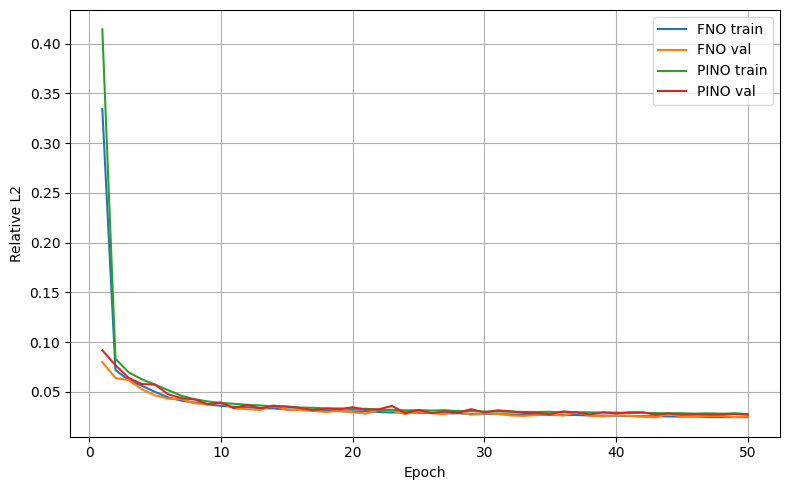

FNO: {'rho': np.float64(0.008742402557017184), 'p': np.float64(0.3462144779034288), 'u1': np.float64(0.14127854560551342), 'u2': np.float64(0.02948646611864126), 'u3': np.float64(0.010528977156632115), 'B1': np.float64(0.006858670890339041), 'B2': np.float64(0.028932322520353496), 'B3': np.float64(0.00788711804655024), 'Mean_first5': 0.10725017386824656, 'All': 0.07249112259980944, 'Time_s': 7.33325799999875e-05}
PINO: {'rho': np.float64(0.008493741052200033), 'p': np.float64(0.3512057055751585), 'u1': np.float64(0.1532491798156113), 'u2': np.float64(0.032939715976556906), 'u3': np.float64(0.009304440190943867), 'B1': np.float64(0.007444245839582425), 'B2': np.float64(0.036734600221912404), 'B3': np.float64(0.008795368424523947), 'Mean_first5': 0.11103855652209413, 'All': 0.07602087463706117, 'Time_s': 5.5336099999931316e-05}
FNO divB: 0.07010643721671542 0.15374557262021485
PINO divB: 0.03717501835265304 0.05414738056161574


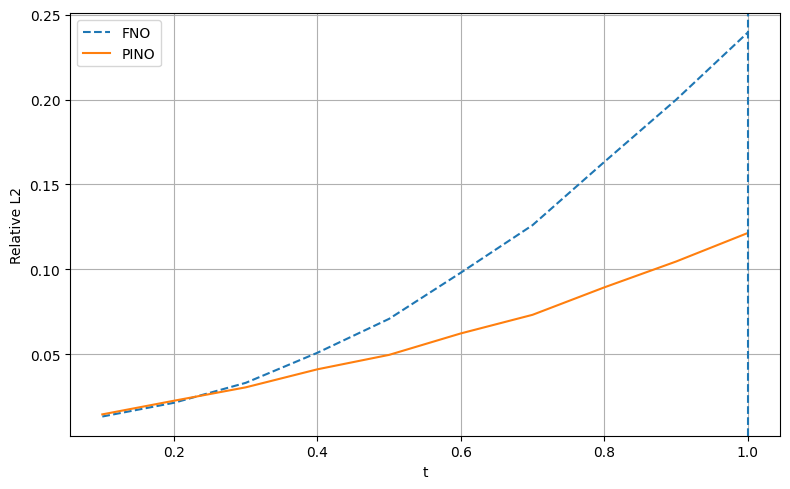

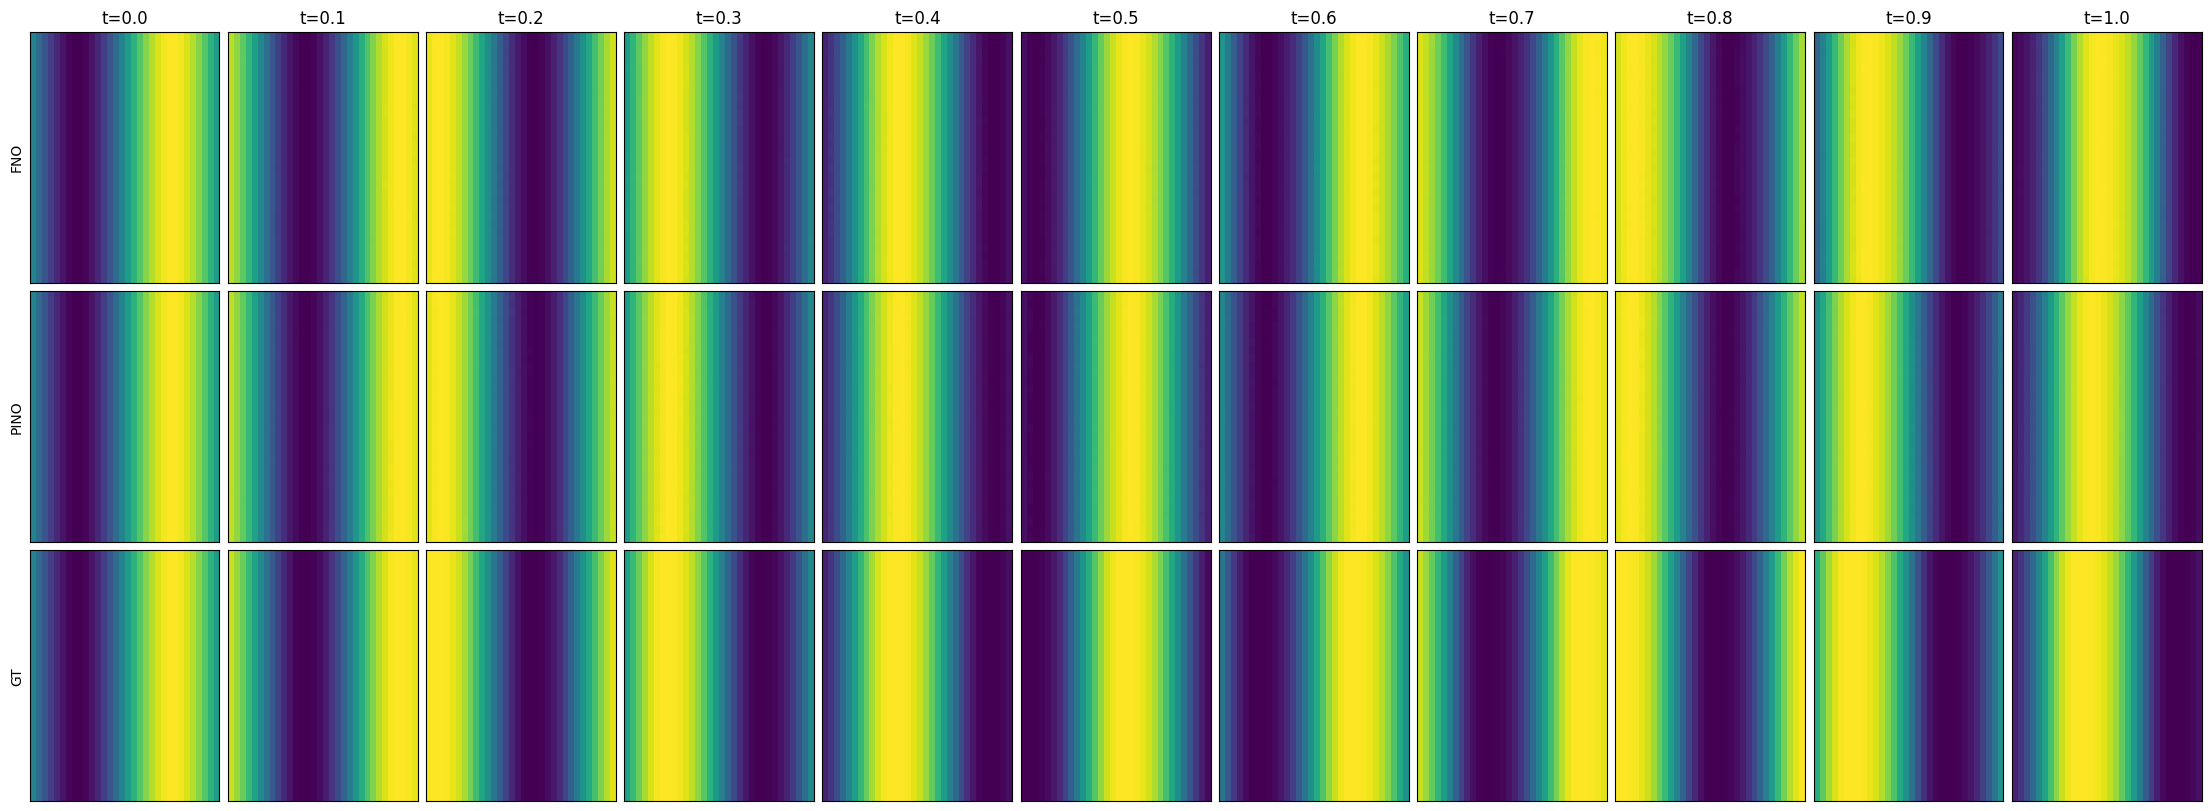

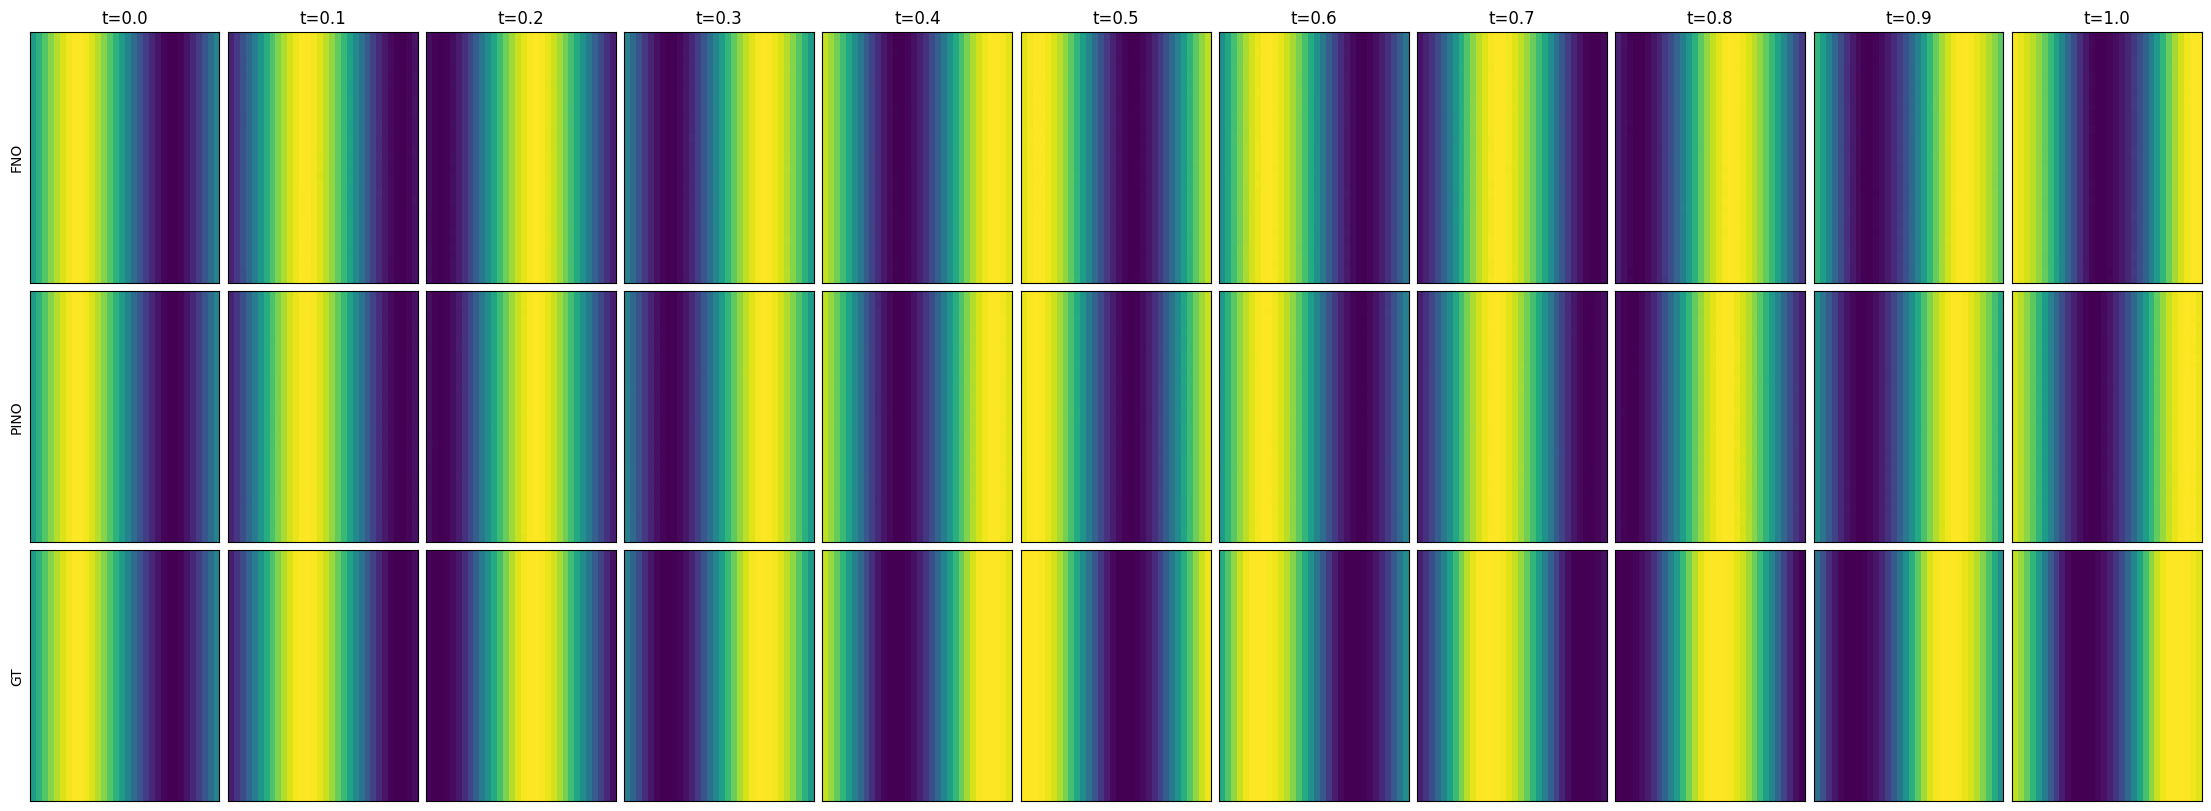

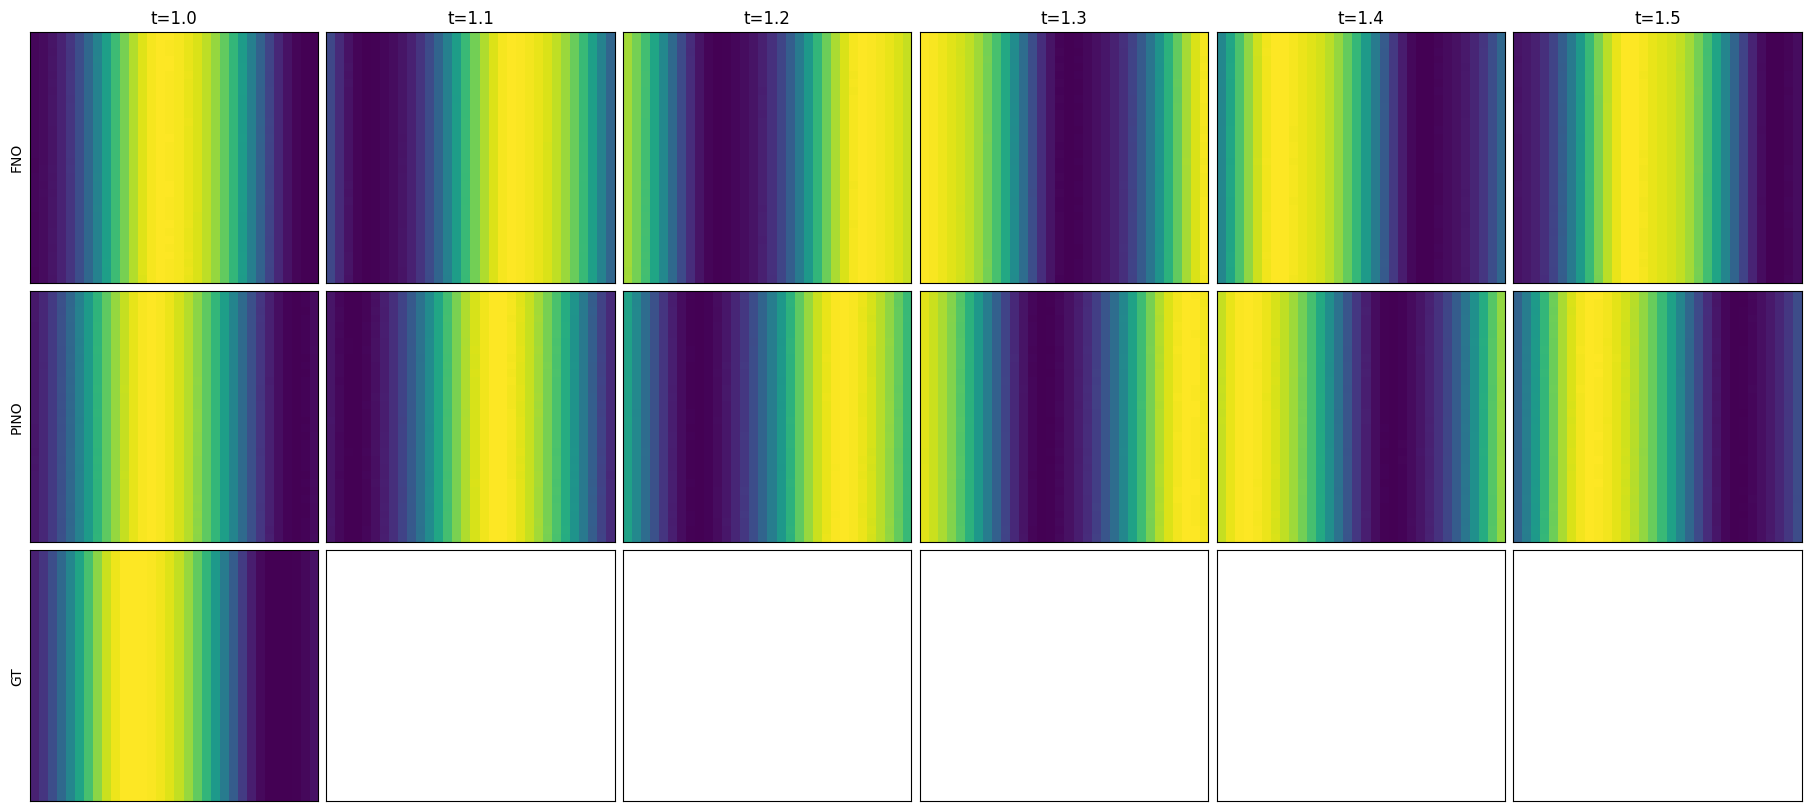

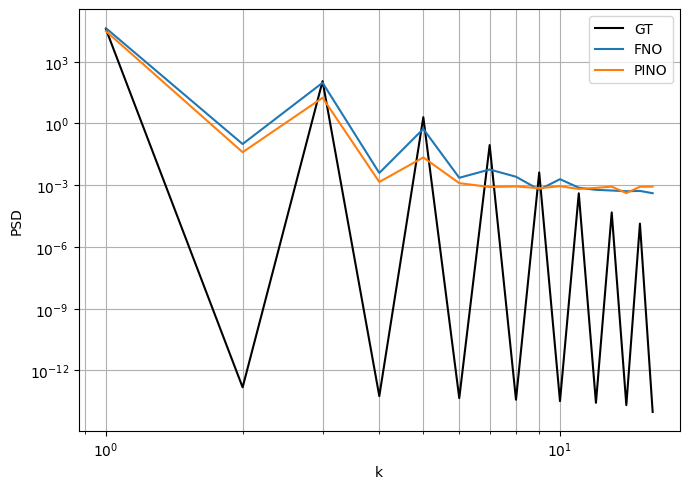

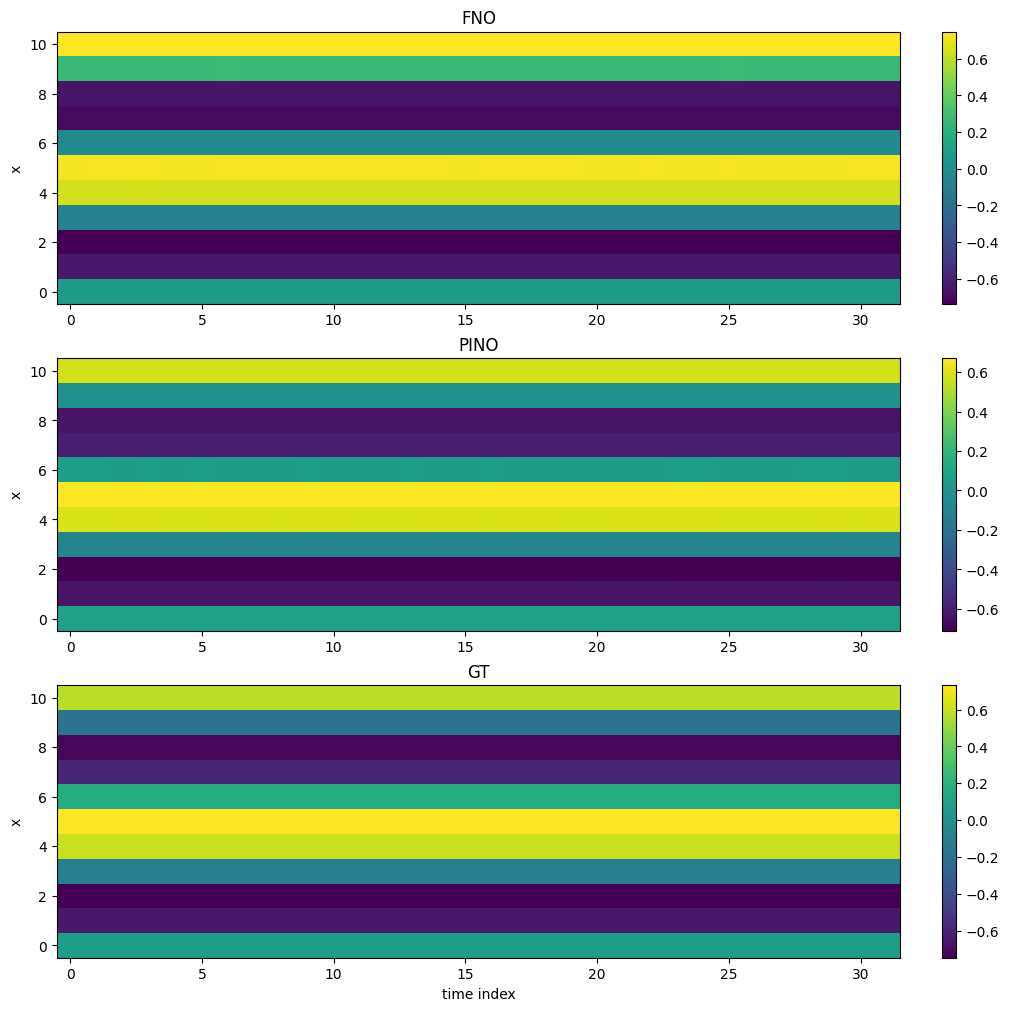

Estimated ridge slope (FNO): 1.727272727272727
Estimated ridge slope (PINO): 0.5363636363636362


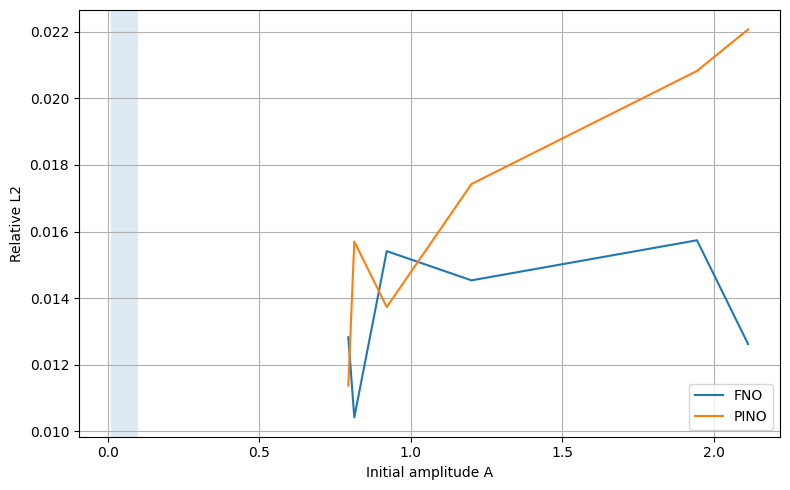

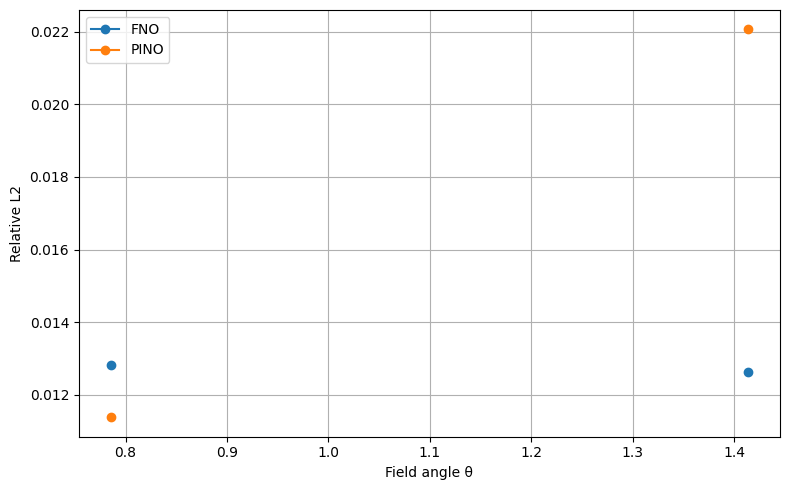

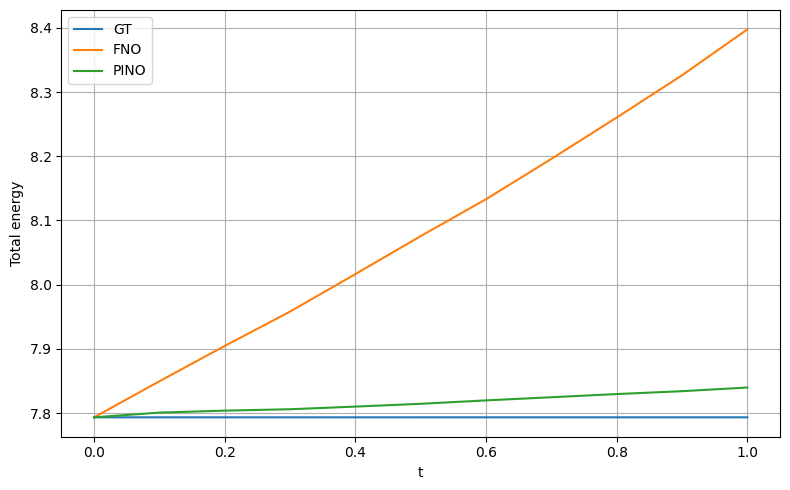

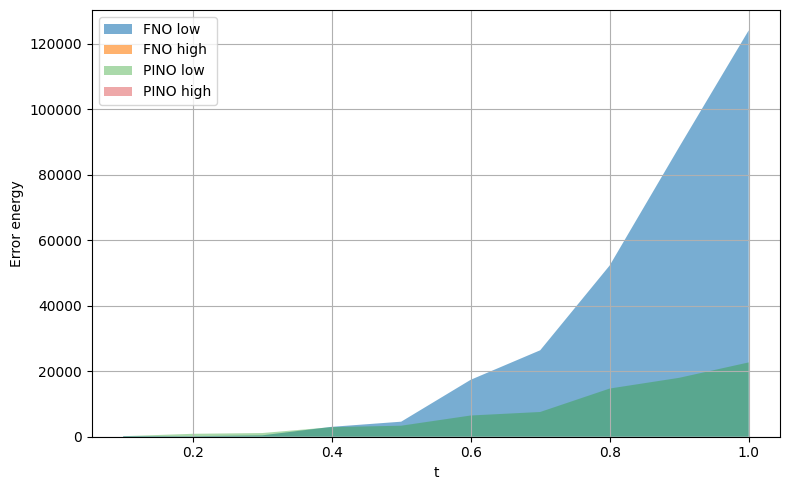

FNO ms/sample: 0.05786825000004683
PINO ms/sample: 0.060206490000018674
Epoch 001 | train 0.329976 | val 0.078704
Epoch 002 | train 0.070484 | val 0.067578
Epoch 003 | train 0.061469 | val 0.058113
Epoch 004 | train 0.054336 | val 0.049258
Epoch 005 | train 0.048333 | val 0.045598
Epoch 006 | train 0.045350 | val 0.044250
Epoch 007 | train 0.043484 | val 0.042791
Epoch 008 | train 0.042264 | val 0.040516
Epoch 009 | train 0.040969 | val 0.040490
Epoch 010 | train 0.040020 | val 0.039027
Epoch 011 | train 0.039327 | val 0.038900
Epoch 012 | train 0.038822 | val 0.039408
Epoch 013 | train 0.038180 | val 0.035955
Epoch 014 | train 0.037371 | val 0.041084
Epoch 015 | train 0.037051 | val 0.035928
Epoch 016 | train 0.036745 | val 0.037194
Epoch 017 | train 0.036125 | val 0.035757
Epoch 018 | train 0.035930 | val 0.036299
Epoch 019 | train 0.035662 | val 0.034293
Epoch 020 | train 0.035047 | val 0.034400
Epoch 021 | train 0.034958 | val 0.035354


KeyboardInterrupt: 

In [15]:
    # ══════════════════════════════════════════════════════════════════════════
    # Load best weights
    # ══════════════════════════════════════════════════════════════════════════
fno_model  = load_weights(build_fno(), "fno_best.pt")
pino_model = load_weights(build_fno(), "pino_best.pt")

    # ── Fig 8.1 ───────────────────────────────────────────────────────────────
plot_learning_curves()

    # ── Tables 8.3 / 9.7 ─────────────────────────────────────────────────────
fno_total,  fno_row  = one_step_table(fno_model,  test_loader)
pino_total, pino_row = one_step_table(pino_model, test_loader)
print("FNO:", fno_row)
print("PINO:", pino_row)

    # ── Table 8.4 ─────────────────────────────────────────────────────────────
test_indices           = list(range(0, 100, 10))
fno_div1,  fno_div10  = divB_table(fno_model,  X, Y, test_indices)
pino_div1, pino_div10 = divB_table(pino_model, X, Y, test_indices)
print("FNO divB:",  fno_div1,  fno_div10)
print("PINO divB:", pino_div1, pino_div10)

    # ── Fig 8.2 ───────────────────────────────────────────────────────────────
plot_rollout_error_curve(X, Y, sim_ids=[0, 1, 2, 3],
                             fno_model=fno_model, pino_model=pino_model,
                             steps=10, save_path="fig_8_2.png")

    # ── Figs 9.3, 9.4 ────────────────────────────────────────────────────────
plot_rollout_panel(X, Y, sim_id=0, fno_model=fno_model,
                       pino_model=pino_model, channel=U3,
                       save_path="fig_9_3_uz.png", n_steps=10)
plot_rollout_panel(X, Y, sim_id=0, fno_model=fno_model,
                       pino_model=pino_model, channel=B3,
                       save_path="fig_9_4_bz.png", n_steps=10)

    # ── Fig 9.5 ───────────────────────────────────────────────────────────────
plot_extrapolation_panel(X, Y, sim_id=0, fno_model=fno_model,
                             pino_model=pino_model, channel=U3,
                             save_path="fig_9_5_extrapolation.png", steps=15)

    # ── Fig 9.8 ───────────────────────────────────────────────────────────────
plot_psd_compare(X, Y, sim_id=0, fno_model=fno_model,
                     pino_model=pino_model, channel=U3, step=10,
                     save_path="fig_9_8_psd.png")

    # ── Fig 9.9 ───────────────────────────────────────────────────────────────
plot_hovmoller_and_speed(X, Y, sim_id=0, fno_model=fno_model,
                              pino_model=pino_model, channel=U3,
                              save_path="fig_9_9_hovmoller.png")

    # ── Fig 9.10 ──────────────────────────────────────────────────────────────
plot_amplitude_sensitivity(X, Y, test_sim_ids=list(range(6)),
                             fno_model=fno_model, pino_model=pino_model,
                                save_path="fig_9_10_amp.png")

    # ── Fig 9.11 ──────────────────────────────────────────────────────────────
plot_angle_sensitivity(X, Y, test_sim_ids=list(range(8)),
                            fno_model=fno_model, pino_model=pino_model,
                            save_path="fig_9_11_angle.png", bins=5)

    # ── Fig 9.12 ──────────────────────────────────────────────────────────────
plot_energy_rollout(X, Y, sim_id=0, fno_model=fno_model,
                        pino_model=pino_model, steps=10,
                        save_path="fig_9_12_energy.png")

    # ── Fig 9.13 ──────────────────────────────────────────────────────────────
plot_freq_decomp(X, Y, sim_id=0, fno_model=fno_model,
                     pino_model=pino_model, channel=U3, steps=10,
                     save_path="fig_9_13_freq.png")

    # ── Timing ────────────────────────────────────────────────────────────────
print("FNO ms/sample:",  benchmark_model(fno_model,  test_loader))
print("PINO ms/sample:", benchmark_model(pino_model, test_loader))

    # ══════════════════════════════════════════════════════════════════════════
    # FNO ablation  (Table 9.1)
    # ══════════════════════════════════════════════════════════════════════════
ablation_cfgs = [(4, 32), (8, 32), (12, 64), (16, 64), (20, 64), (16, 128)]
rows = []
for kmax, dv in ablation_cfgs:
    model     = build_fno(n_modes=(kmax, kmax), hidden_channels=dv)
    optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=100)
    train_with_logging(
            model, train_loader, val_loader, optimizer, scheduler,
            epochs=100,
            csv_path=f"fno_k{kmax}_dv{dv}.csv",
            ckpt_path=f"fno_k{kmax}_dv{dv}.pt",
            pde_loss_fn=None,
        )
    tmp_total, _ = one_step_table(model, test_loader)
    rows.append({"kmax": kmax, "dv": dv, "test_error": tmp_total})
pd.DataFrame(rows).to_csv("table_9_1_fno_ablation.csv", index=False)

    # ══════════════════════════════════════════════════════════════════════════
    # PINO lambda sweep  (Table 9.2)
    # ══════════════════════════════════════════════════════════════════════════
lambdas = [0.0, 0.01, 0.1, 0.5, 1.0]
rows    = []
for lam in lambdas:
    model     = build_fno()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(
          optimizer, step_size=50, gamma=0.5)
    lam_loss  = PINOAlfvenLoss(dt=DT, spectral=spectral, mu0=1.0)
    train_with_logging(
            model, train_loader, val_loader, optimizer, scheduler,
            epochs=100,
            csv_path=f"pino_lam{lam}.csv",
            ckpt_path=f"pino_lam{lam}.pt",
            pde_loss_fn=lam_loss,
            lambda_pde=lam,
        )
    total, row = one_step_table(model, test_loader)
    rows.append({
            "lambda":      lam,
            "data_loss":   row["All"],
            "pde_residual": np.nan,
            "divB":        np.nan,
        })
pd.DataFrame(rows).to_csv("table_9_2_pino_lambda_sweep.csv", index=False)